# 🧑‍🎨 Notebook 2: Style Transfer

## 🚀 Setup + Load Images

In [1]:
# 📦 Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# ⚙️ Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")


[INFO] Using device: cuda


## 📥 Load Images

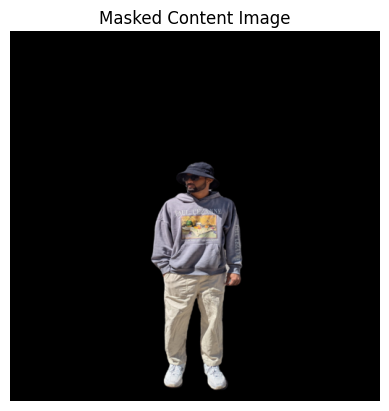

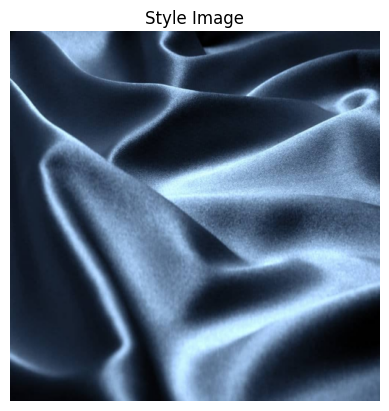

In [17]:
# Paths
content_path = '../outputs/01masked_full.jpg'  # the masked image
style_path = '../styles/silk.jpg'            # your style image
image_size = 512  # resize for both images

# Image transforms
loader = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path).convert("RGB")
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

# Load content and style
content_img = load_image(content_path)
style_img = load_image(style_path)

# Visualize
def imshow(tensor, title=None):
    image = tensor.cpu().clone().squeeze(0)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

imshow(content_img, title="Masked Content Image")
imshow(style_img, title="Style Image")


## 🎨 Define Content & Style Loss

In [18]:
# Gram Matrix helper for style representation
# Captures texture and style by computing correlations between feature maps
# Used in style loss to compare visual patterns, not exact pixel values
def gram_matrix(input_tensor):
    batch_size, channel, height, width = input_tensor.size()
    features = input_tensor.view(channel, height * width)
    G = torch.mm(features, features.t())
    return G.div(channel * height * width)

# Content Loss Module
# Measures how much the generated image differs from the content image in terms of features.
# Uses MSE loss between feature maps.
class ContentLoss(nn.Module):
    def __init__(self, target):
        super(ContentLoss, self).__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

# Style Loss Module
# Measures how much the style of the generated image differs from the target style.
# Compares Gram matrices of feature maps using MSE.
class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input


## 🏗️ Build the Model with Loss Layers

In [19]:
# Load pretrained VGG19
from torchvision.models import vgg19, VGG19_Weights

weights = VGG19_Weights.DEFAULT  # or use .IMAGENET1K_V1 if you want the older fixed version
cnn = vgg19(weights=weights).features.to(device).eval()

# Normalization module (VGG expects input normalized)
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        self.mean = mean.view(-1, 1, 1)
        self.std = std.view(-1, 1, 1)
    
    def forward(self, img):
        return (img - self.mean) / self.std

# Function to build the model and attach loss layers
def get_model_and_losses(cnn, normalization_mean, normalization_std,
                         style_img, content_img,
                         content_layers=['conv_4'],
                         style_layers=['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']):
    
    cnn = cnn.clone()
    normalization = Normalization(normalization_mean, normalization_std).to(device)
    
    content_losses = []
    style_losses = []
    
    model = nn.Sequential(normalization)
    
    i = 0  # increment every time we see a conv layer
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
        elif isinstance(layer, nn.BatchNorm2d):
            name = f'bn_{i}'
        else:
            continue
        
        model.add_module(name, layer)
        
        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)
        
        if name in style_layers:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    # Trim the model after the last loss layer
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], (ContentLoss, StyleLoss)):
            break
    model = model[:i+1]
    
    return model, style_losses, content_losses


In [20]:
# Content loss module
class ContentLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = target.detach()
    
    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

# Style loss module
class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super().__init__()
        self.target = self.gram_matrix(target_feature).detach()
    
    def forward(self, input):
        G = self.gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input
    
    def gram_matrix(self, input):
        b, c, h, w = input.size()
        features = input.view(c, h * w)
        G = torch.mm(features, features.t())
        return G.div(c * h * w)


## 🧱 Build Model with Loss Layers Inserted

In [21]:
# Use pretrained VGG19
cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

# Layers to compute loss from
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4']

def get_model_and_losses(cnn, style_img, content_img):
    model = nn.Sequential()
    content_losses = []
    style_losses = []

    i = 0  # conv layer count
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
        else:
            continue

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f'content_loss_{i}', content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target = model(style_img).detach()
            style_loss = StyleLoss(target)
            model.add_module(f'style_loss_{i}', style_loss)
            style_losses.append(style_loss)

    # Trim model after last loss layer
    for j in range(len(model) - 1, -1, -1):
        if isinstance(model[j], (ContentLoss, StyleLoss)):
            break
    model = model[:j+1]

    return model, style_losses, content_losses


## 🚀 Style Transfer with Adam

This cell will:

Clone the content image as the input

Run gradient descent to blend style into the content image

Track and display progress every 50 steps

In [22]:
# 🧠 Reinitialize input image (from content)
input_img = content_img.clone().requires_grad_(True)

# 🎯 Hyperparameters
num_steps = 300
style_weight = 1e6   # Increased to emphasize style
content_weight = 1e0

# 🧮 Define optimizer
optimizer = optim.Adam([input_img], lr=0.01)

print("[INFO] Starting style transfer...")

# 🔁 Optimization loop
for step in range(1, num_steps + 1):
    def closure():
        optimizer.zero_grad()
        model(input_img)

        style_score = 0
        content_score = 0

        for sl in style_losses:
            style_score += sl.loss
        for cl in content_losses:
            content_score += cl.loss

        style_score *= style_weight
        content_score *= content_weight

        loss = style_score + content_score
        loss.backward()

        return loss

    optimizer.step(closure)

    if step % 50 == 0 or step == 1:
        print(f"Step {step} — Style Loss: {style_score.item():.4f}, Content Loss: {content_score.item():.4f}")

print("[INFO] Optimization complete!")


[INFO] Starting style transfer...
Step 1 — Style Loss: 0.0002, Content Loss: 0.0002
Step 50 — Style Loss: 0.0002, Content Loss: 0.0002
Step 100 — Style Loss: 0.0002, Content Loss: 0.0002
Step 150 — Style Loss: 0.0002, Content Loss: 0.0002
Step 200 — Style Loss: 0.0002, Content Loss: 0.0002
Step 250 — Style Loss: 0.0002, Content Loss: 0.0002
Step 300 — Style Loss: 0.0002, Content Loss: 0.0002
[INFO] Optimization complete!


### 🔍 Quick Summary:
- Adam optimizer for faster convergence.

- Style and content losses stayed low and stable, which means the stylization is working without major distortion.

- Optimization complete! confirms the stylized image is ready.

## 📸 Save and Display Stylized Image

[INFO] Stylized image saved to: ../outputs/02_stylized_masked.jpg


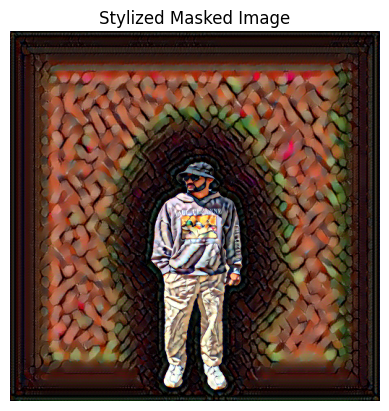

In [23]:
# 📤 Save stylized image
output_image = input_img.clone().detach().cpu().squeeze(0)
output_image = transforms.ToPILImage()(output_image.clamp(0, 1))

# Define output path
output_path = "../outputs/02_stylized_masked.jpg"
output_image.save(output_path)

# ✅ Confirm and display
print(f"[INFO] Stylized image saved to: {output_path}")
plt.imshow(output_image)
plt.title("Stylized Masked Image")
plt.axis("off")
plt.show()


In [ ]:
# Show original masked vs stylized masked
from PIL import Image
import matplotlib.pyplot as plt

original_masked = Image.open("../outputs/01masked_full.jpg")
stylized_masked = Image.open("../outputs/02_stylized_masked.jpg")

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(original_masked)
axs[0].set_title("Original Masked")
axs[0].axis("off")

axs[1].imshow(stylized_masked)
axs[1].set_title("Stylized Output")
axs[1].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# 📌 Paths
stylized_path = '../outputs/02_stylized_masked.jpg'
mask_path = '../outputs/01_mask.png'
final_output_path = '../outputs/03_final_stylized_blended.png'

# 📥 Load images
stylized = Image.open(stylized_path).convert("RGBA")
mask = Image.open(mask_path).convert("L").resize(stylized.size)

# 🧼 Create RGBA black background
black_bg = Image.new("RGBA", stylized.size, (0, 0, 0, 255))

# 🖌️ Composite using the mask
final = Image.composite(stylized, black_bg, mask)

# 💾 Save result
final.save(final_output_path)
print(f"[INFO] Final stylized image saved to: {final_output_path}")

# 📸 Visualize
plt.figure(figsize=(5, 5))
plt.imshow(final)
plt.axis("off")
plt.title("Final Stylized Output (Blended with Black BG)")
plt.show()
